# Economic News Analysis - Exploratory Data Analysis (EDA)
**Project:** Economic News NLP Dashboard  
**Author:** Mikel  
**Date:** January 2026  

This notebook explores the raw data ingested from GDELT. The goal is to understand the media landscape, 
identify key economic topics, and prepare the data for Sentiment Analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar el archivo procesado más reciente
processed_path = "../data/processed/"
latest_file = max([os.path.join(processed_path, f) for f in os.listdir(processed_path)], key=os.path.getctime)
df = pd.read_csv(latest_file)

print(f"Dataset loaded: {len(df)} articles")
df.head()

Dataset loaded: 243 articles


,url,url_mobile,title,seendate,socialimage,domain,language,sourcecountry,clean_title,source_name
0,https://www.larepublica.co/globoeconomia/econo...,https://amp.larepublica.co/globoeconomia/econo...,Economía de EE . UU . se expandió a un ritmo r...,20260122T183000Z,https://img.lalr.co/cms/2026/01/22102604/web_g...,larepublica.co,Spanish,Colombia,economía de ee uu se expandió a un ritmo rev...,larepublica.co
1,https://www.elfinanciero.com.mx/bloomberg-busi...,NaN,No entres en pánico por una recesión,20260126T173000Z,https://www.elfinanciero.com.mx/resizer/v2/WRA...,elfinanciero.com.mx,Spanish,Mexico,no entres en pánico por una recesión,elfinanciero.com.mx
2,https://www.opinion.com.bo/articulo/pais/rebaj...,https://www.opinion.com.bo/articulo/pais/rebaj...,De reducir el déficit fiscal y la inflación a ...,20260120T220000Z,https://www.opinion.com.bo/media/opinion/image...,opinion.com.bo,Spanish,Bolivia,de reducir el déficit fiscal y la inflación a ...,opinion.com.bo
3,https://www.elcaribe.com.do/opiniones/fogarate...,NaN,La reserva federal,20260121T050000Z,NaN,elcaribe.com.do,Spanish,Dominican Republic,la reserva federal,elcaribe.com.do
4,https://www.eleconomista.es/economia/noticias/...,NaN,La gran crisis de Rusia empezará cuando dejen ...,20260122T071500Z,https://s03.s3c.es/imag/_v0/3864x2109/0/f/e/12...,eleconomista.es,Spanish,Spain,la gran crisis de rusia empezará cuando dejen ...,eleconomista.es


C:\Users\Mikel\AppData\Local\Temp\ipykernel_8248\4005464267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette="viridis")


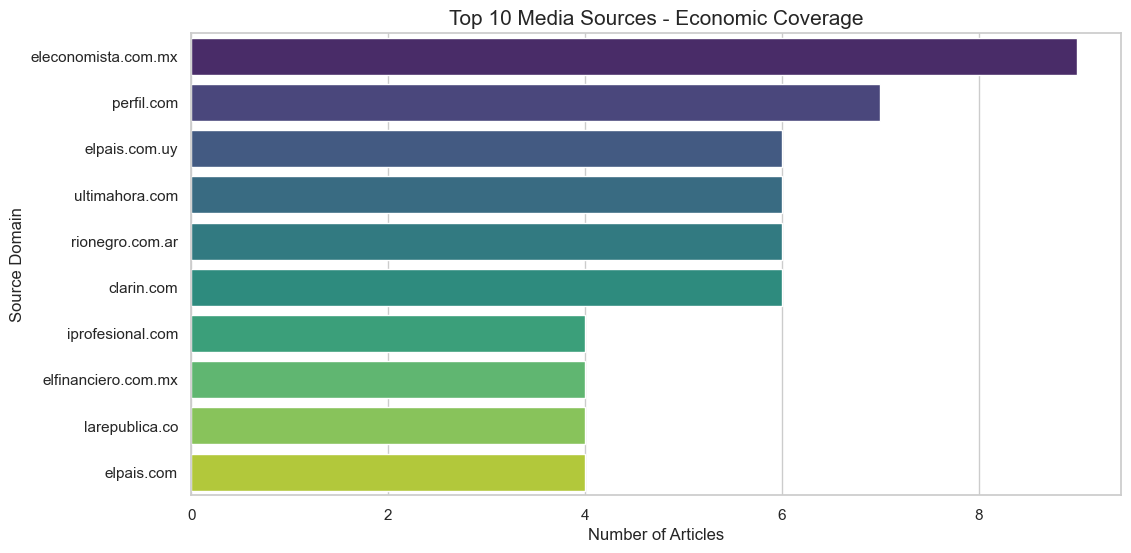

In [2]:
top_sources = df['source_name'].value_counts().head(10)

sns.barplot(x=top_sources.values, y=top_sources.index, palette="viridis")
plt.title("Top 10 Media Sources - Economic Coverage", fontsize=15)
plt.xlabel("Number of Articles")
plt.ylabel("Source Domain")
plt.show()

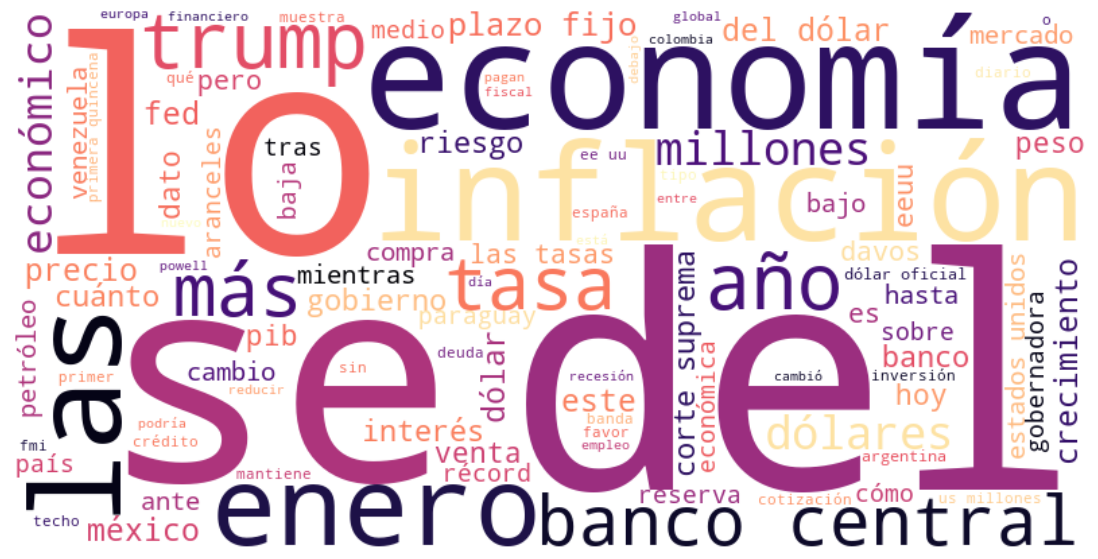

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english')).union(set(stopwords.words('spanish')))
text = " ".join(title for title in df.clean_title)


wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    stopwords=stop_words, 
    colormap='magma', 
    max_words=100
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

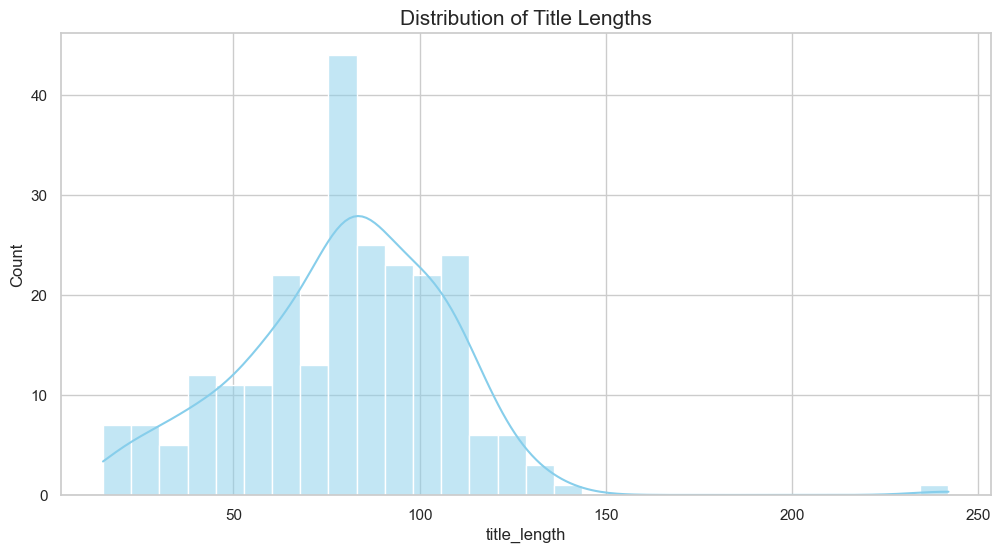

In [8]:
df['title_length'] = df['clean_title'].apply(len)
sns.histplot(df['title_length'], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Title Lengths", fontsize=15)
plt.show()